In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ✈️ Customer Segmentation and Actionable Retention Strategies

Now that we have churn predictions for all customers, the next step is to group them into meaningful segments based on their value and behavior. This notebook performs unsupervised clustering (K-means) to discover natural customer groupings, then assigns targeted retention actions to each segment. The output is a strategic roadmap for how to engage different customer types to maximize retention and lifetime value.

In [ ]:
df = pd.read_csv("Scored_Dataset.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Churn Risk distribution:\n{df['Churn_Risk'].value_counts()}")

Shape: (13520, 30)
Columns: ['Unnamed: 0', 'Loyalty Number', 'Salary', 'CLV', 'Salary_Was_Imputed', 'Male_Enc', 'Marital_Enc', 'Education_Enc', 'Card_Enc', 'Promo_Enroll', 'Tenure_At_Cutoff', 'Churn', 'Total_Flights', 'Total_Distance', 'Total_Points_Acc', 'Total_Points_Red', 'Active_Months', 'Max_Flights_Month', 'Total_Months', 'Avg_Flights_Month', 'Activity_Rate', 'Redemption_Ratio', 'Avg_Distance_Per_Flight', 'Months_Since_Last_Flight', 'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4', 'Churn_Prob', 'Churn_Risk']
Churn Risk distribution:
Churn_Risk
Low       10632
Medium     1860
High       1028
Name: count, dtype: int64


## Loading Scored Dataset

We start by loading the dataset we created in the Model Training notebook. This includes churn probabilities and risk categories for all customers, which we'll now use to segment them into actionable groups.

In [ ]:
seg_features = [
    'Total_Flights',             # Frequency
    'Months_Since_Last_Flight',  # Recency
    'CLV',                       # Value
    'Redemption_Ratio',          # Engagement
    'Activity_Rate',             # Consistency
    'Tenure_At_Cutoff',          # Loyalty duration
    'Card_Enc'                   # Loyalty tier
]

seg_df = df[['Loyalty Number'] + seg_features].copy()
seg_df.fillna(0, inplace=True)

scaler = StandardScaler()
X_seg = scaler.fit_transform(seg_df[seg_features])

print(f"Segmentation matrix shape: {X_seg.shape}")

Segmentation matrix shape: (13520, 7)


## Feature Selection for Segmentation

We don't use all features for clustering—instead, we focus on 7 key behavioral and value metrics that best capture customer differences:

- **Total_Flights**: How frequently they fly (engagement level)
- **Months_Since_Last_Flight**: How recently they were active (recency)
- **CLV**: How much they're worth (value)
- **Redemption_Ratio**: How engaged they are with the loyalty program
- **Activity_Rate**: Consistency of their engagement
- **Tenure_At_Cutoff**: How long they've been members (loyalty duration)
- **Card_Enc**: Loyalty tier (elite customers vs casual)

We then standardize these features so each is on the same scale (0 mean, unit variance), which is crucial for K-means clustering to work fairly.

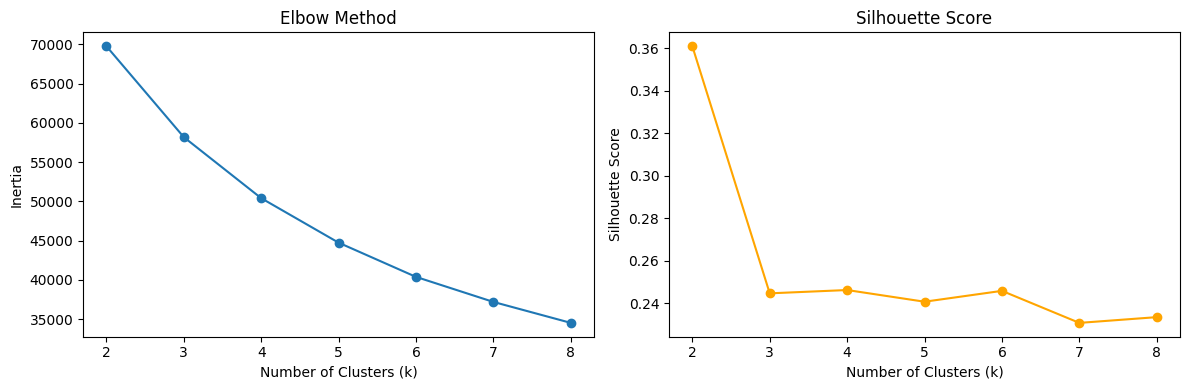


Silhouette Scores:
  k=2: 0.3610
  k=3: 0.2446
  k=4: 0.2461
  k=5: 0.2406
  k=6: 0.2458
  k=7: 0.2307
  k=8: 0.2334


In [ ]:
inertias     = []
silhouettes  = []
K_range      = range(2, 9)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

## Finding the Optimal Number of Segments

The key question: how many customer segments should we create? Too few and we miss important differences; too many and strategies become unwieldy. We use two methods to decide:

1. **Elbow Method**: Plot inertia (within-cluster sum of squares) vs k. Look for the "elbow" where adding more clusters stops giving diminishing returns.
2. **Silhouette Score**: Ranges from -1 to 1. Higher means clusters are more distinct and well-separated. We want scores closer to 1.

Both methods guide us toward the optimal k.

In [ ]:
# Choose K based on elbow + silhouette above
BEST_K = 4

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
seg_df['Segment_ID'] = km_final.fit_predict(X_seg)

# Merge segments back to full dataset
profile = df.merge(seg_df[['Loyalty Number', 'Segment_ID']],
                   on='Loyalty Number', how='left')

print(f"Segment distribution:\n{profile['Segment_ID'].value_counts()}")

Segment distribution:
Segment_ID
3    6130
2    2952
1    2939
0    1499
Name: count, dtype: int64


## Fit K-Means Clustering

Based on the elbow method and silhouette score, we select the optimal k and fit the K-means algorithm. Each customer gets assigned to exactly one segment (0, 1, 2, ..., k-1) based on which cluster centroid they're closest to.

In [ ]:
cluster_summary = profile.groupby('Segment_ID').agg(
    Count                    = ('Loyalty Number', 'count'),
    Avg_CLV                  = ('CLV', 'mean'),
    Avg_Flights              = ('Total_Flights', 'mean'),
    Avg_Recency              = ('Months_Since_Last_Flight', 'mean'),
    Avg_Activity_Rate        = ('Activity_Rate', 'mean'),
    Avg_Redemption           = ('Redemption_Ratio', 'mean'),
    Avg_Tenure               = ('Tenure_At_Cutoff', 'mean'),
    Avg_Churn_Prob           = ('Churn_Prob', 'mean'),
).round(2)

print(cluster_summary.to_string())

            Count   Avg_CLV  Avg_Flights  Avg_Recency  Avg_Activity_Rate  Avg_Redemption  Avg_Tenure  Avg_Churn_Prob
Segment_ID                                                                                                          
0            1499   8457.39         0.49        11.68               0.02            0.00       37.65            0.10
1            2939   6795.85        10.23         1.12               0.33            0.03       12.37            0.29
2            2952  13698.73        20.22         0.66               0.61            0.02       37.53            0.05
3            6130   5671.09        20.88         0.59               0.63            0.02       41.63            0.05


## Segment Profiles: Understand Each Cluster

Now let's see what each segment actually looks like. We compute key metrics (average CLV, flights, activity, churn probability, etc.) for each cluster. This tells us who's in each segment and what characterizes them.

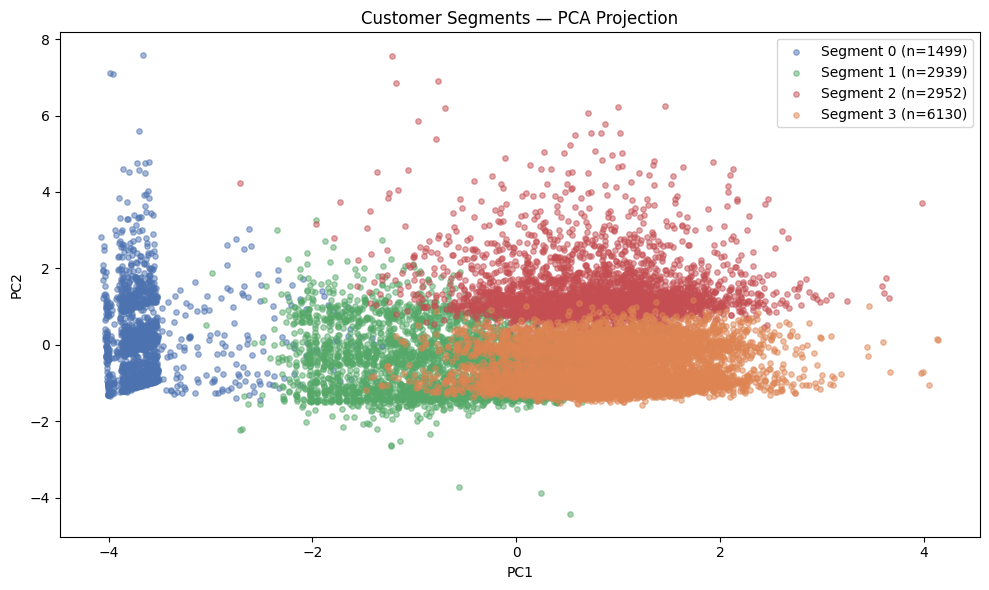

In [ ]:
pca  = PCA(n_components=2, random_state=42)
pcs  = pca.fit_transform(X_seg)

seg_df['PC1'] = pcs[:, 0]
seg_df['PC2'] = pcs[:, 1]

plt.figure(figsize=(10, 6))
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']
for seg in range(BEST_K):
    mask = seg_df['Segment_ID'] == seg
    plt.scatter(
        seg_df.loc[mask, 'PC1'],
        seg_df.loc[mask, 'PC2'],
        label=f'Segment {seg} (n={mask.sum()})',
        alpha=0.5, s=15,
        color=colors[seg]
    )
plt.legend()
plt.title("Customer Segments — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Visualizing Segments with PCA

To see these segments visually, we use PCA (Principal Component Analysis) to reduce the 7 features down to 2 dimensions while preserving as much variation as possible. The scatter plot shows each customer as a point, colored by segment. Well-separated clusters are good—they indicate distinct customer groups.

In [ ]:
crosstab = pd.crosstab(
    profile['Segment_ID'],
    profile['Churn_Risk'],
    margins=True
)
print("Segment vs Churn Risk:\n")
print(crosstab.to_string())

Segment vs Churn Risk:

Churn_Risk  High    Low  Medium    All
Segment_ID                            
0            101   1234     164   1499
1            880    883    1176   2939
2             31   2743     178   2952
3             16   5772     342   6130
All         1028  10632    1860  13520


## Cross-tabulation: Segments vs. Churn Risk

This crosstab shows how churn risk is distributed across segments. Some segments will have mostly low-risk customers (easy to retain), while others are dominated by high-risk customers (urgent intervention needed). This helps prioritize where to focus retention efforts.

In [ ]:
segment_names = {
    0: "Dormant Members",        # barely flew, long inactive, moderate churn
    1: "New At-Risk",            # recently enrolled, low flights, highest churn risk
    2: "High Value Vulnerables", # highest CLV but still 49% churn prob — most important to save
    3: "Stable Regulars"         # largest group, long tenure, moderate churn
}

profile['Segment_Name'] = profile['Segment_ID'].map(segment_names)
seg_df['Segment_Name']  = seg_df['Segment_ID'].map(segment_names)

print(profile['Segment_Name'].value_counts())

Segment_Name
Stable Regulars           6130
High Value Vulnerables    2952
New At-Risk               2939
Dormant Members           1499
Name: count, dtype: int64


## Naming Segments: From Numbers to Stories

Raw cluster IDs (0, 1, 2, 3) don't tell a business story. By looking at the segment profiles—CLV, flight frequency, recency, churn probability—we can give each segment a meaningful business name that describes their value and risk. This makes it easy for stakeholders to understand and act on the insights.

In [ ]:
named_summary = profile.groupby('Segment_Name').agg(
    Count             = ('Loyalty Number', 'count'),
    Avg_CLV           = ('CLV', 'mean'),
    Avg_Flights       = ('Total_Flights', 'mean'),
    Months_Inactive   = ('Months_Since_Last_Flight', 'mean'),
    Activity_Rate     = ('Activity_Rate', 'mean'),
    Avg_Churn_Prob    = ('Churn_Prob', 'mean'),
    High_Risk_Count   = ('Churn_Risk', lambda x: (x == 'High').sum()),
).round(2)

print(named_summary.to_string())

                        Count   Avg_CLV  Avg_Flights  Months_Inactive  Activity_Rate  Avg_Churn_Prob  High_Risk_Count
Segment_Name                                                                                                         
Dormant Members          1499   8457.39         0.49            11.68           0.02            0.10              101
High Value Vulnerables   2952  13698.73        20.22             0.66           0.61            0.05               31
New At-Risk              2939   6795.85        10.23             1.12           0.33            0.29              880
Stable Regulars          6130   5671.09        20.88             0.59           0.63            0.05               16


## Segment Summary: The Executive View

Here's a clean summary of each named segment, showing size, value, and risk. This table tells us at a glance:
- How many customers are in each segment
- How much they're worth on average (CLV)
- How active they are (flights, activity rate)
- How churned-out they are already (months inactive)
- Their predicted churn probability

In [ ]:
# This is the final file the dashboard will use
final_df = profile[[
    'Loyalty Number', 'Salary', 'CLV', 'Card_Enc',
    'Tenure_At_Cutoff', 'Promo_Enroll',
    'Total_Flights', 'Months_Since_Last_Flight',
    'Activity_Rate', 'Redemption_Ratio',
    'Avg_Flights_Month', 'Avg_Distance_Per_Flight',
    'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4',
    'Churn', 'Churn_Prob', 'Churn_Risk',
    'Segment_ID', 'Segment_Name'
]].copy()

final_df.to_csv("Final_Segments.csv", index=False)
print(f"Shape: {final_df.shape}")
print(f"\nSegment distribution:\n{final_df['Segment_Name'].value_counts()}")
print(f"\nChurn Risk distribution:\n{final_df['Churn_Risk'].value_counts()}")

Shape: (13520, 21)

Segment distribution:
Segment_Name
Stable Regulars           6130
High Value Vulnerables    2952
New At-Risk               2939
Dormant Members           1499
Name: count, dtype: int64

Churn Risk distribution:
Churn_Risk
Low       10632
Medium     1860
High       1028
Name: count, dtype: int64


## Building the Final Dataset with Recommended Actions

Now we move from segmentation to action. For each customer, we design a specific retention strategy based on:
- Their segment (e.g., "New At-Risk" vs "Stable Regulars")
- Their churn probability
- Their CLV (high-value customers get premium treatment)
- Their recency (inactive customers need urgent re-engagement)

Each strategy includes:
- **Action Code**: A simple label (e.g., "VIP WIN-BACK", "NURTURE")
- **Recommended Action**: The specific tactic (e.g., "Personal call + upgrade voucher")
- **Timing**: When to execute (e.g., "Within 7 days" vs "Ongoing")

This is the actionable output: a playbook for the retention team.

In [ ]:
def assign_action(row):
    prob     = row['Churn_Prob']
    segment  = row['Segment_Name']
    clv      = row['CLV']
    clv_75   = profile['CLV'].quantile(0.75)
    inactive = row['Months_Since_Last_Flight']

    if segment == "New At-Risk":
        return ("WIN-BACK",
                "Email: 2x points on next booking valid 30 days",
                "Within 7 days")

    elif segment == "Dormant Members":
        return ("RE-ENGAGE",
                "Push notification: personalised fare deal on top routes",
                "Immediate-before they lapse completely")

    elif segment == "High Value Vulnerables" and clv > clv_75:
        return ("VIP WIN-BACK",
                "Personal call from account manager + upgrade voucher + 5000 bonus points",
                "Within 7 days-urgent")

    elif segment == "High Value Vulnerables":
        return ("VALUE SAVE",
                "Targeted email: exclusive double points event this month",
                "Within 14 days")

    elif segment == "Stable Regulars" and prob > 0.15:
        return ("PROACTIVE SAVE",
                "Loyalty challenge: fly 2 more times this quarter for tier upgrade",
                "Start of quarter")

    else:
        return ("NURTURE",
                "Monthly newsletter + birthday bonus points",
                "Ongoing")

actions  = profile.apply(assign_action, axis=1, result_type='expand')
actions.columns = ['Action_Code', 'Recommended_Action', 'Timing']
final_df = pd.concat([final_df.reset_index(drop=True), actions], axis=1)

print("Action distribution:")
print(final_df['Action_Code'].value_counts())

final_df.to_csv("Final_Segments.csv", index=False)

Action distribution:
Action_Code
NURTURE           5772
WIN-BACK          2939
VIP WIN-BACK      1727
RE-ENGAGE         1499
VALUE SAVE        1225
PROACTIVE SAVE     358
Name: count, dtype: int64
